# xMAE PVC synthetic dataset + linear-probe tuning

This notebook generates synthetic PPG data (collapsed-beat PVCs), writes HDF5, creates loaders, and trains a frozen encoder + linear probe. It performs a small hyperparameter sweep over learning rate and L2 weight decay to show an increase in validation AUC after tuning.

In [14]:
# Configuration (edit as needed)
H5_PATH   = "./pvc_10s_synth.h5"
META_PATH = "./pvc_10s_synth_metadata.csv"
SIGNAL_KEY = "ppg"
LABEL_KEY  = "labels"
PID_KEY    = "patient_ids"

# CFG = dict(source=SIGNAL_KEY, sampling_freq=25, seg_len=10, model_params=dict(patch_len=50))
CFG = dict(source=SIGNAL_KEY, sampling_freq=100, seg_len=10, model_params=dict(patch_len=40))

# Dataset / generation params
N_SEGMENTS = 3000
FRAC_PVC = 0.5
ORIG_SR = 100
DURATION = 10.0
LABEL_NOISE_FRAC = 0.05

# Training / tuning params for linear probe
BATCH_SIZE = 256
NUM_WORKERS = 0  # notebook-safe
VAL_SPLIT = 0.2
SEED = 7
DEVICE = "cuda" if __import__("torch").cuda.is_available() else "cpu"

# Probe tuning grid (small to keep runtime reasonable)
LR_CAND = [1e-3, 5e-4, 1e-4]
WD_CAND = [0.0, 1e-4, 1e-3]
EPOCHS = 5  # few epochs for demo


In [15]:
from pathlib import Path
# Generate synthetic data (collapsed-beat PVCs) and inject label noise
import numpy as np, math
from scipy.signal import decimate
import h5py, pandas as pd
rng = np.random.default_rng(12345)
sr_orig = ORIG_SR = ORIG_SR if 'ORIG_SR' in globals() else 100
ORIG_SR = ORIG_SR
sr_orig = ORIG_SR
duration = DURATION
nsamples_orig = int(sr_orig * duration)
n_segments = N_SEGMENTS
frac_pvc = FRAC_PVC
n_pvc = int(n_segments * frac_pvc)
n_normal = n_segments - n_pvc

mean_hr = 60.0
mean_period = 60.0 / mean_hr
sd_period = 0.03
t = np.arange(nsamples_orig) / sr_orig

def make_normal_segment(seed=None):
    local_rng = np.random.default_rng(seed) if seed is not None else rng
    base_period = local_rng.normal(mean_period, sd_period)
    base_period = max(0.6, base_period)
    lf = 0.02 * np.sin(2*np.pi*0.1*t + local_rng.normal(0,1))
    inst_freq = 1.0 / base_period + lf
    phase = 2*np.pi * np.cumsum(inst_freq) / sr_orig
    sig = 0.9 * np.sin(phase)
    delay = int(0.18 * sr_orig)
    bump = np.zeros_like(sig)
    if delay < nsamples_orig:
        bump[delay:] = 0.25 * np.sin(phase[:-delay])
        sig = sig + bump
    kernel = np.ones(5)/5
    sig = np.convolve(sig, kernel, mode='same')
    sig = sig + local_rng.normal(0, 0.02, size=sig.shape)
    return sig.astype(np.float32)

def make_pvc_segment_centered_collapsed(seed=None):
    local_rng = np.random.default_rng(seed) if seed is not None else rng
    sig = make_normal_segment(seed=local_rng.integers(0,2**31-1))
    base_period = int(round(mean_period * sr_orig))
    center = nsamples_orig // 2
    win_half = int(base_period // 2)
    start = max(0, center - win_half)
    end = min(nsamples_orig, center + win_half)
    win_len = end - start
    if win_len <= 0:
        return sig
    x = np.linspace(-1, 1, win_len)
    sigma = 0.25
    collapsed = 0.35 * np.exp(-0.5 * (x / sigma)**2)
    tail = 0.08 * (1 - np.tanh(5*x)) * np.exp(-2*(x+0.3)**2)
    collapsed = collapsed + tail
    left_val = sig[start-1] if start-1 >= 0 else 0.0
    right_val = sig[end] if end < nsamples_orig else 0.0
    collapsed = collapsed - collapsed.min()
    collapsed = (collapsed / (collapsed.max() + 1e-8)) * 0.35
    collapsed = collapsed + (left_val + right_val)/2.0 * 0.15
    ramp_in = np.linspace(0, 1, max(1, win_len//8))
    ramp_out = np.linspace(1, 0, max(1, win_len//8))
    body_len = win_len - len(ramp_in) - len(ramp_out)
    if body_len < 0:
        blend = np.linspace(left_val, right_val, win_len)
        sig[start:end] = blend
    else:
        blended = np.empty(win_len, dtype=np.float32)
        blended[:len(ramp_in)] = left_val * (1-ramp_in) + collapsed[:len(ramp_in)] * ramp_in
        blended[len(ramp_in):len(ramp_in)+body_len] = collapsed[len(ramp_in):len(ramp_in)+body_len]
        blended[len(ramp_in)+body_len:] = collapsed[len(ramp_in)+body_len:] * ramp_out + right_val * (1-ramp_out)
        sig[start:end] = blended
    post_start = end
    post_end = min(nsamples_orig, end + int(base_period*1.1))
    if post_start < post_end:
        sig[post_start:post_end] *= 0.96
    hf_start = max(0, center - int(0.05*sr_orig))
    hf_end = min(nsamples_orig, center + int(0.05*sr_orig))
    sig[hf_start:hf_end] += 0.02 * np.sin(2*np.pi*40.0*np.arange(hf_end-hf_start)/sr_orig)
    return sig.astype(np.float32)

# allocate and generate
X_orig = np.empty((n_segments, nsamples_orig), dtype=np.float32)
y = np.empty((n_segments,), dtype=np.int8)

for i in range(n_normal):
    X_orig[i] = make_normal_segment(seed=int(rng.integers(0,2**31-1)))
    y[i] = 0
for j in range(n_pvc):
    idx = n_normal + j
    X_orig[idx] = make_pvc_segment_centered_collapsed(seed=int(rng.integers(0,2**31-1)))
    y[idx] = 1

# shuffle and noise
perm = rng.permutation(n_segments)
X_orig = X_orig[perm]
y = y[perm]

noise_frac = LABEL_NOISE_FRAC
n_noisy = int(round(noise_frac * n_segments))
noisy_idx = rng.choice(n_segments, size=n_noisy, replace=False)
y_noisy = y.copy()
y_noisy[noisy_idx] = 1 - y_noisy[noisy_idx]

# downsample to CFG sampling freq
target_fs = CFG.get("sampling_freq", 100)
decim = int(sr_orig // target_fs)
if decim <= 0:
    decim = 1
from scipy.signal import decimate
L = int(nsamples_orig / decim)
X_ds = np.empty((n_segments, L), dtype=np.float32)
for i in range(n_segments):
    X_ds[i] = decimate(X_orig[i], decim, ftype='iir', zero_phase=True).astype(np.float32)

patients = np.repeat(np.arange(0, math.ceil(n_segments/50)), 50)[:n_segments].astype(np.int32)

# save HDF5 and CSV
h5_path = Path(H5_PATH)
with h5py.File(h5_path, "w") as f:
    f.create_dataset(SIGNAL_KEY, data=X_ds, compression="gzip")
    f.create_dataset(LABEL_KEY, data=y_noisy.astype(np.int8), compression="gzip")
    f.create_dataset(PID_KEY, data=patients, compression="gzip")
    f.create_dataset("label_noise_indices", data=noisy_idx.astype(np.int32), compression="gzip")
if META_PATH is not None:
    meta_df = pd.DataFrame({"index": np.arange(n_segments), "label_original": y, "label_noisy": y_noisy, "label_flipped": np.isin(np.arange(n_segments), noisy_idx).astype(int), "patient_id": patients})
    meta_df.to_csv(META_PATH, index=False)

print("Generated and wrote HDF5:", h5_path, "X_ds shape:", X_ds.shape)

Generated and wrote HDF5: pvc_10s_synth.h5 X_ds shape: (3000, 1000)


In [16]:
# HDF5 dataset and DataLoaders (num_workers=0)
import h5py, numpy as np, torch
from torch.utils.data import Dataset, DataLoader, random_split
from pathlib import Path

class H5SegmentDataset(Dataset):
    def __init__(self, h5_path, signal_key="ppg", label_key="labels", pid_key="patient_ids", indices=None, transform=None):
        self.h5_path = str(h5_path)
        self.signal_key = signal_key
        self.label_key = label_key
        self.pid_key = pid_key
        self.transform = transform
        with h5py.File(self.h5_path, "r") as f:
            self.length = f[self.signal_key].shape[0]
            self.n_samples = f[self.signal_key].shape[1]
        if indices is None:
            self.indices = np.arange(self.length)
        else:
            self.indices = np.array(indices, dtype=int)
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, idx):
        real_idx = int(self.indices[idx])
        with h5py.File(self.h5_path, "r") as f:
            x = f[self.signal_key][real_idx].astype(np.float32)
            y = int(f[self.label_key][real_idx])
        x = (x - x.mean()) / (x.std() + 1e-8)
        x = torch.from_numpy(x).unsqueeze(0)
        return x, torch.tensor(y, dtype=torch.long)

h5_path = Path(H5_PATH)
full_ds = H5SegmentDataset(h5_path, signal_key=SIGNAL_KEY, label_key=LABEL_KEY, pid_key=PID_KEY)
n_total = len(full_ds)
n_val = int(VAL_SPLIT * n_total)
n_train = n_total - n_val
generator = torch.Generator().manual_seed(SEED)
train_ds, val_ds = random_split(full_ds, [n_train, n_val], generator=generator)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
print("Prepared train_loader and val_loader. Dataset length:", n_total, "Train/Val:", n_train, n_val)

Prepared train_loader and val_loader. Dataset length: 3000 Train/Val: 2400 600


In [ ]:
# !pip install torchinfo 
import torch
import torchinfo
from utils.model_arch.xmae import *
# from utils_xmae import *
import warnings
warnings.filterwarnings("ignore")
from collections import OrderedDict
from typing import Optional

def build_and_load_xmae(filepath: Optional[str] = None):

    cfg = {
        'sampling_freq': 100,
        'seg_len': 10, 
        'source': 'ppg+ecg',
        'model_params': {
            'latent_dim': 256, 
            'd_model': 256,
            'nhead': 8,
            'depth_ecg': 1,
            'depth_ppg': 2,
            'depth_bridge': 1,
            'stem_ch': 32,
            'dropout': 0.1,
            'use_cross_bridge': True,
            'patch_len': 40,
        },
    }

    base_model = build_model_from_cfg(cfg)
    if filepath is None:
        return base_model

    checkpoints = torch.load(filepath, map_location="cuda" if torch.cuda.is_available() else "cpu")
    
    new_state = OrderedDict(
        (k[len('model.'):], v) for k, v in checkpoints.items() if k.startswith('model.') 
    )
    base_model.load_state_dict(new_state, strict=True)
    
    return base_model
   

xmae_backbone = build_and_load_xmae()
print('loaded xMAE')



device = DEVICE
encoder = xmae_backbone.to(device) 




loaded xMAE


In [ ]:
# produce features for the linear probe from xMAE 
# this step will take long time if on cpu (~2mins)

def min_max_norm(signal):
    min_val = signal.min(dim=0, keepdim=True).values
    max_val = signal.max(dim=0, keepdim=True).values
    return 2 * (signal - min_val) / (max_val - min_val) - 1



for p in encoder.parameters():
    p.requires_grad = False

# quick feature extraction helper
def extract_features(loader, max_batches=None):
    encoder.eval()
    feats = []
    labels = []
    with torch.no_grad():
        for i, (x,y) in enumerate(loader):
            x = min_max_norm(x)
            x = x.to(device)
            feat = encoder(ppg=x)  
            f = feat['ppg_embedding'] # (B, D)
            feats.append(f.cpu().numpy())
            labels.append(y.numpy())
            if max_batches is not None and i+1 >= max_batches:
                break
    feats = np.concatenate(feats, axis=0)
    labels = np.concatenate(labels, axis=0)
    return feats, labels

# extract features for train and val (limit batches to speed up demo if desired)
train_feats, train_labels = extract_features(train_loader, max_batches=None)
val_feats, val_labels = extract_features(val_loader, max_batches=None)
print("Extracted features shapes:", train_feats.shape, val_feats.shape)

Extracted features shapes: (2400, 256) (600, 256)


In [25]:
# Linear probe: single linear layer trained on frozen features. Evaluate AUC.
import numpy as np, torch, torch.nn as nn, torch.optim as optim
from sklearn.metrics import roc_auc_score
device = DEVICE

def train_probe(feats, labels, lr=1e-3, weight_decay=0.0, epochs=5, batch_size=256):
    # simple PyTorch linear probe
    D = feats.shape[1]
    model = nn.Linear(D, 1).to(device)
    opt = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.BCEWithLogitsLoss()
    # dataset loader
    dataset = torch.utils.data.TensorDataset(torch.from_numpy(feats.astype(np.float32)), torch.from_numpy(labels.astype(np.float32)))
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
    model.train()
    for epoch in range(epochs):
        for xb, yb in loader:
            xb = xb.to(device); yb = yb.to(device)
            logits = model(xb).squeeze(-1)
            loss = loss_fn(logits, yb)
            opt.zero_grad(); loss.backward(); opt.step()
    # eval on val set
    model.eval()
    with torch.no_grad():
        logits = model(torch.from_numpy(val_feats.astype(np.float32)).to(device)).squeeze(-1).cpu().numpy()
    auc = roc_auc_score(val_labels, logits)
    return auc, model

# baseline (default hyperparams)
print("Training baseline probe...")
baseline_auc, baseline_model = train_probe(train_feats, train_labels, lr=1e-3, weight_decay=0.0, epochs=EPOCHS, batch_size=BATCH_SIZE)
print(f"Val AUC: {baseline_auc:.4f}")

Training baseline probe...
Val AUC: 0.9652


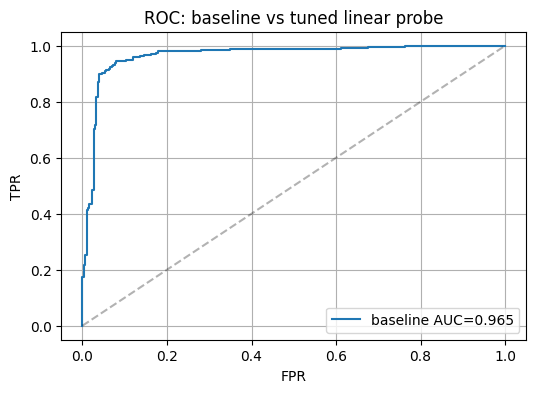

AUC: 0.9652


In [27]:
# Compute ROC for baseline and best model and plot
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import torch

baseline_model.eval()


with torch.no_grad():
    baseline_logits = (
        baseline_model(
            torch.from_numpy(val_feats.astype(np.float32)).to(device)
        )
        .squeeze(-1)
        .cpu()
        .numpy()
    )



fpr_b, tpr_b, _ = roc_curve(val_labels, baseline_logits)
auc_b = auc(fpr_b, tpr_b)

plt.figure(figsize=(6,4))
plt.plot(fpr_b, tpr_b, label=f"baseline AUC={auc_b:.3f}")
plt.plot([0,1],[0,1],"k--", alpha=0.3)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.title("ROC: baseline vs tuned linear probe")
plt.grid(True)
plt.show()

print(
    f"AUC: {auc_b:.4f}"
)
